# Capítulo 4: Series de Tiempo. Caso de Estudio 1: Clima

> Dora María Ballesteros  
> Primera edición, 2026  
> ISBN: 978-1-957395-63-0  
> 🔗 **[Consultar el libro en Editorial REDIPE](https://editorial.redipe.org/index.php/1/catalog/book/245)**

**Versión:** Septiembre de 2026

---

## Material complementario del libro

Este notebook acompaña el **Capítulo 4** del libro *Investigación en Ciencia de Datos* y continúa el desarrollo del **Caso de Estudio 1: Clima**.

En el notebook anterior se realizó el **Análisis Exploratorio de Datos (EDA) aplicado a Series de Tiempo**, estudiando la evolución temporal de las variables, la dependencia entre diferentes series y la relación entre valores actuales y pasados.

En este notebook utilizaremos el **dataset resultante de ese proceso de EDA** para aplicar **Feature Engineering (FE)**. Las nuevas características se construirán a partir de los patrones identificados durante la exploración de los datos, especialmente aquellos relacionados con su comportamiento temporal.

Posteriormente, se realizará nuevamente el **modelamiento**, utilizando el mismo problema de predicción, con el propósito de comparar los resultados obtenidos **antes y después de aplicar Feature Engineering**.

El objetivo será responder una pregunta:

**¿La información obtenida durante el EDA puede utilizarse para construir nuevas características que mejoren la capacidad predictiva del modelo?**

# **1. Lectura y previsualización del dataset**

In [1]:
import pandas as pd
clima_df = pd.read_csv("/content/clima_eda.csv")
clima_df.head()

,tiempo_hora_local,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_num
0,2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4
1,2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4
2,2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4
3,2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4
4,2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4


**CONVERTIR LA COLUMNDA DE TIEMPO A ÍNDICE**

In [2]:
clima_df["tiempo_hora_local"] = pd.to_datetime(clima_df["tiempo_hora_local"])
clima_df = clima_df.set_index("tiempo_hora_local")

In [3]:
clima_df.head()

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_num
tiempo_hora_local,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4


# **2.  Feature Engineering**

**FEATURES TEMPORALES**

Día de la semana

La propiedad `dayofweek` de un índice temporal en Pandas identifica el día de la semana utilizando valores entre **0 y 6**, donde **0 corresponde al lunes y 6 al domingo**.

En este caso se suma `1` para utilizar una representación más intuitiva:

**1 = lunes, 2 = martes, ..., 7 = domingo.**

In [4]:

clima_df["hora"] = clima_df.index.hour
clima_df["dia_semana"] = clima_df.index.dayofweek +1

In [5]:
clima_df.head(10)

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_num,hora,dia_semana
tiempo_hora_local,,,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4,0,2
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4,1,2
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4,2,2
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4,3,2
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4,4,2
2019-10-01 05:00:00,23.0,1.0,21.56,94.0,2.09,4.47,1008.03,0.0,271.6,0.0,4,5,2
2019-10-01 06:00:00,24.0,1.0,21.97,95.0,2.31,4.07,1008.61,0.0,271.8,0.0,4,6,2
2019-10-01 07:00:00,25.0,1.0,22.34,96.0,2.98,4.65,1008.97,0.0,272.4,0.0,3,7,2
2019-10-01 08:00:00,25.0,1.0,22.35,99.0,3.44,5.14,1009.53,1.0,272.8,0.0,3,8,2


**TIPO LAG**

In [6]:
columnas_lag  = [
    "temperatura",
    "humedad",
    "presion",
    "punto_rocio",
    "direccion_viento",
    "velocidad_viento",
    "rafagas_viento",
    "presion",
    "indice_UV",
    "ozono",
    "intensidad_precipitacion"
]

lags = [12, 24, 48, 72]


for columna in columnas_lag:
    for lag in lags:
        clima_df[f"{columna}_lag_{lag}"] = (
            clima_df[columna].shift(lag)
        )

In [7]:
clima_df.head(10)

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,...,indice_UV_lag_48,indice_UV_lag_72,ozono_lag_12,ozono_lag_24,ozono_lag_48,ozono_lag_72,intensidad_precipitacion_lag_12,intensidad_precipitacion_lag_24,intensidad_precipitacion_lag_48,intensidad_precipitacion_lag_72
tiempo_hora_local,,,,,,,,,,,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 05:00:00,23.0,1.0,21.56,94.0,2.09,4.47,1008.03,0.0,271.6,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 06:00:00,24.0,1.0,21.97,95.0,2.31,4.07,1008.61,0.0,271.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 07:00:00,25.0,1.0,22.34,96.0,2.98,4.65,1008.97,0.0,272.4,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01 08:00:00,25.0,1.0,22.35,99.0,3.44,5.14,1009.53,1.0,272.8,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
clima_df = clima_df.dropna()

# **3.  MODELAMIENTO**

In [9]:
# Variable objetivo
y = clima_df['estado_clima_num']

# Variables predictoras
X = clima_df.drop(columns=['estado_clima_num'])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (427, 52)
Dimensión de y: (427,)


In [10]:
# Punto de corte: 70 % entrenamiento - 30 % prueba
punto_corte = int(len(clima_df) * 0.7)

# División temporal
X_train = X.iloc[:punto_corte]
X_test  = X.iloc[punto_corte:]

y_train = y.iloc[:punto_corte]
y_test  = y.iloc[punto_corte:]

print("Observaciones de entrenamiento:", len(X_train))
print("Observaciones de prueba:", len(X_test))

print("\nPeriodo de entrenamiento:")
print(X_train.index.min(), "a", X_train.index.max())

print("\nPeriodo de prueba:")
print(X_test.index.min(), "a", X_test.index.max())

Observaciones de entrenamiento: 298
Observaciones de prueba: 129

Periodo de entrenamiento:
2019-10-04 00:00:00 a 2019-10-16 09:00:00

Periodo de prueba:
2019-10-16 10:00:00 a 2019-10-21 18:00:00


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Modelo FE - hora, dia y lags
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# Predicciones
y_pred = modelo.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print()

# Reporte por clase
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy: 0.7752

              precision    recall  f1-score   support

           1       0.98      0.95      0.97        60
           2       0.61      1.00      0.76        43
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        23

    accuracy                           0.78       129
   macro avg       0.40      0.49      0.43       129
weighted avg       0.66      0.78      0.70       129



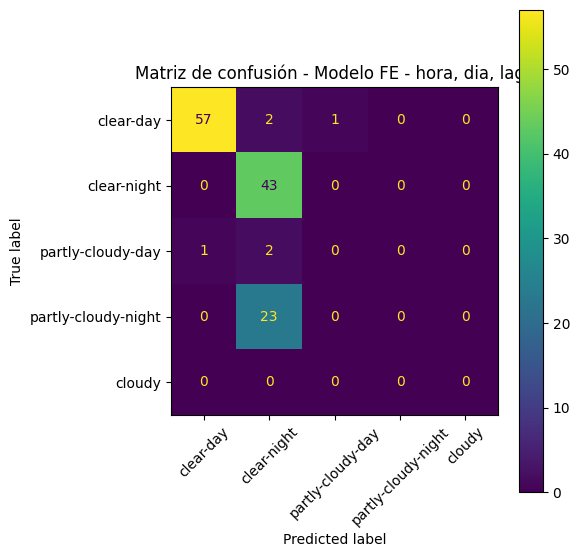

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'clear-day',
        'clear-night',
        'partly-cloudy-day',
        'partly-cloudy-night',
        'cloudy'
    ]
)

disp.plot(ax=ax, xticks_rotation=45)

plt.title('Matriz de confusión - Modelo FE - hora, dia, lags')
plt.tight_layout()
plt.show()

### Importancia de las características

Después de aplicar **Feature Engineering**, podemos analizar cuáles de las características tienen mayor influencia en las decisiones del modelo.

En un Random Forest, la importancia de una característica indica cuánto contribuye a reducir la impureza en los árboles que conforman el modelo. Un valor mayor indica que esa característica fue utilizada con mayor relevancia durante el proceso de clasificación.

Este análisis nos permitirá observar si las nuevas características construidas a partir del comportamiento temporal de los datos están aportando información útil al modelo.

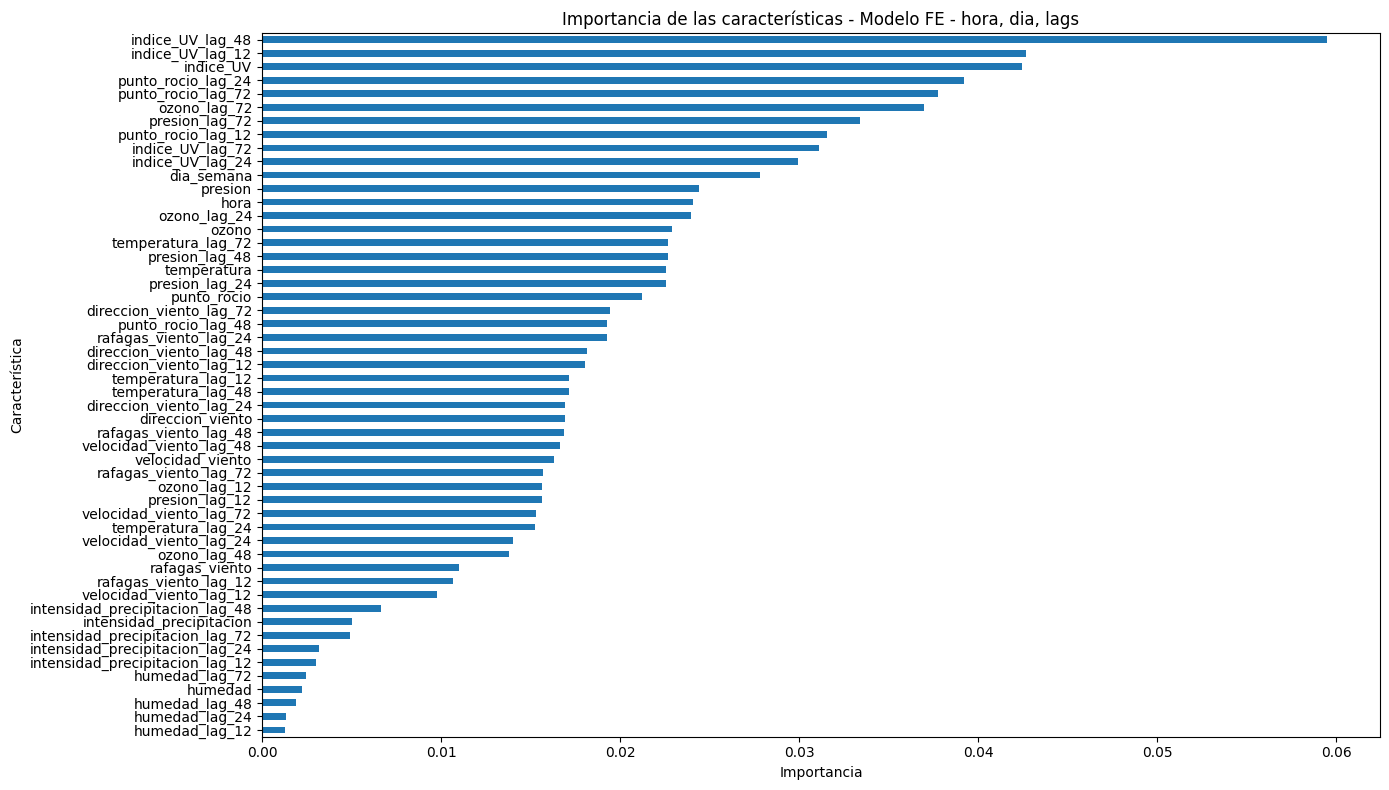

In [15]:
# Importancia de las características

import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(14, 8))
importancias.plot(kind="barh")

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de las características - Modelo FE - hora, dia, lags")

plt.tight_layout()
plt.show()

### 🔎 Análisis de los nuevos features

Los *lags* permiten incorporar como nuevos *features* los valores que tenía una variable en instantes anteriores. En este caso se utilizaron retardos de **12, 24, 48 y 72 horas**.

> 💡 Por ejemplo, un *lag* de 24 horas utiliza como nuevo *feature*
> el valor observado 24 horas antes:
>
> $$
> x_{\text{lag-24}}(t) = x(t-24)
> $$
>
> De esta manera, los nuevos *features* contienen únicamente información disponible en el pasado, sin incorporar valores futuros y, por lo tanto, **sin generar data leakage**.

Al analizar la importancia de las características aparece un resultado interesante: **features que no resultaron especialmente relevantes al aplicar Rolling pueden adquirir una importancia alta cuando se utiliza Lag**.

Esto ocurre, por ejemplo, con variables como **índice UV** y **presión**.

### 🧠 Analiza

Compara estos resultados con los obtenidos anteriormente mediante **Rolling**:

- ¿Qué diferencias encuentras en los nuevos *features* generados a partir del **índice UV** y la **presión** al utilizar Rolling y Lags?

- ¿El mismo valor de *lag* resulta más importante para todas las variables?

- Retoma la **ACF del punto de rocío** analizada durante el EDA. ¿Cuáles *lags* podían identificarse como buenos candidatos para generar nuevos *features*? ¿Cómo se relacionan con los resultados obtenidos?